In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocessing

rng = np.random.default_rng()

In [2]:
def simulate_uniform(
    graph: ig.Graph,
    window: float = 0,
    n_probs: int = 100,
    copies: int = 1000,
    low_p: float = 0.4,
    high_p: float = 0.6,
    no_bar: bool = False,
):
    n_edges = graph.ecount()
    lcc = np.zeros(n_probs, dtype="float32")
    all_prob = np.linspace(max(low_p, window), min(high_p, 1 - window), n_probs)
    for idx, p in tqdm(enumerate(all_prob), total=n_probs, disable=no_bar):
        is_removed = rng.random((copies, n_edges))
        link_prob = rng.uniform(p - window, p + window, (copies, n_edges))
        links_removed = is_removed >= link_prob
        for rep in range(copies):
            links_to_remove = np.flatnonzero(links_removed[rep])
            work = graph.copy()
            work.delete_edges(links_to_remove)
            lcc[idx] += max(work.components().sizes())
        lcc[idx] /= copies
    return all_prob, lcc / graph.vcount()

In [3]:
def parallel(win):
    return simulate_uniform(g.copy(), window=win, low_p=0, high_p=1, n_probs=100, copies=1000, no_bar=True)
    
def run_parallel(graph, name, n_win=11):
    windows = np.linspace(0, 0.5, n_win)
    with multiprocessing.Pool(processes=18) as pool:
        results = pool.imap(parallel, windows)

        prob, lcc = [], []
        for p, temp in tqdm(results, total=n_win):
            prob.append(p)
            lcc.append(temp)
    np.savez(name, windows=windows, prob=prob, lcc=lcc)
    return prob, lcc

In [27]:
g = ig.Graph.Lattice([100, 100], circular=False)
prob, lcc = run_parallel(g, "uniform_grid")

g = ig.Graph.Erdos_Renyi(10000, p=0.0001)
prob, lcc = run_parallel(g, "uniform_er")

g = ig.Graph.Watts_Strogatz(1, 10000, 5, 0.1)
prob, lcc = run_parallel(g, "uniform_ws")

g = ig.Graph.Barabasi(10000, 10)
prob, lcc = run_parallel(g, "uniform_ba")

  0%|          | 0/11 [14:08<?, ?it/s]


KeyboardInterrupt: 

In [4]:
g = ig.Graph.Barabasi(10000, 10)
prob, lcc = run_parallel(g, "uniform_ba")

100%|██████████| 11/11 [24:17<00:00, 132.46s/it]  


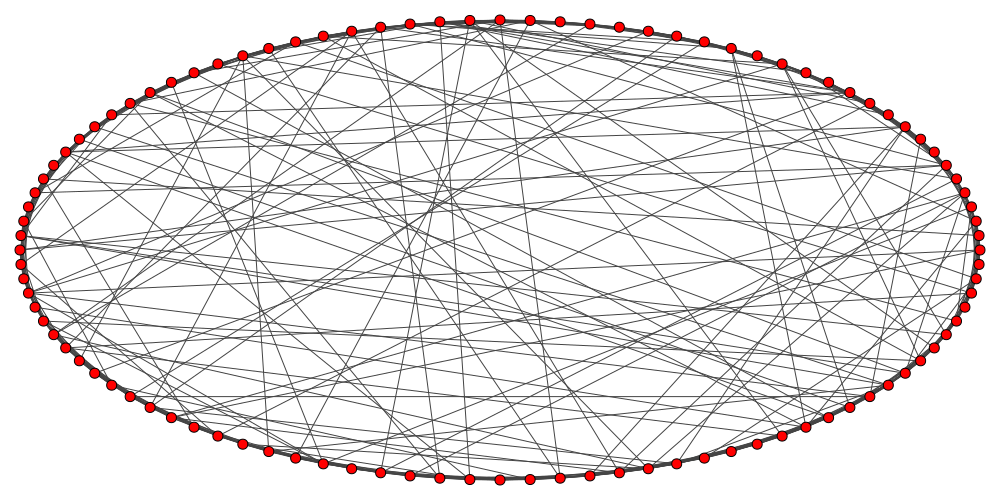

In [20]:
g = ig.Graph.Watts_Strogatz(1, 100, 5, 0.1)
ig.plot(g, layout="circle", bbox=(1000, 500), vertex_size=10)


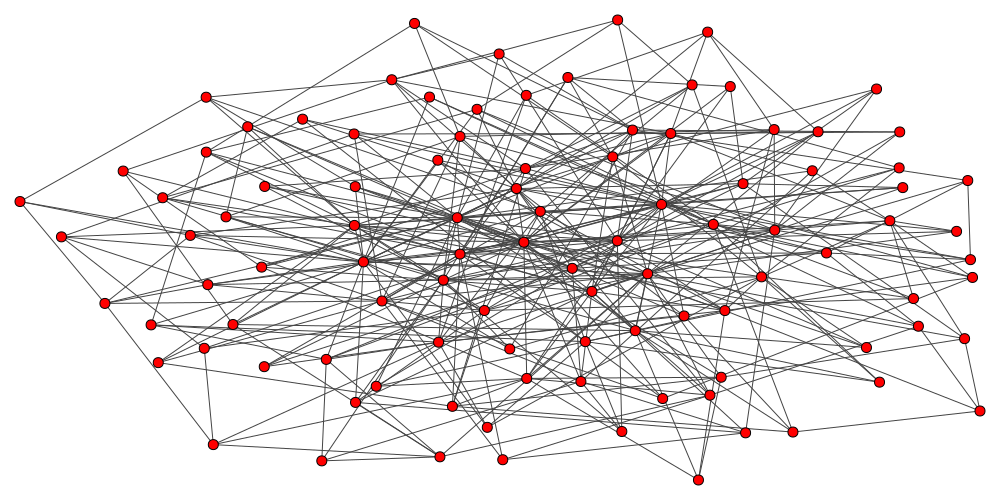

In [26]:
g = ig.Graph.Barabasi(100, 4)
ig.plot(g, layout="auto", bbox=(1000, 500), vertex_size=10)
